# Etap V: Komparatywna Analiza Nierówności i Sprawiedliwości Przestrzennej (Transport Equity)

Etap ten stanowi ostateczną syntetyzę w ujęciu geografii społecznej całego zaplecza badawczego opierając się na miarach dostępności modelu podwójnie ograniczonego. Generuje on narzędzia pomiarowe do wskazania Pustyń Transportowych, nierówności i oceny dysonansu podziałowego majątków społecznych względem usług terytorialnych w metropoliach (Paryż, Dublin, Warszawa).

W tym notatniku zaimplementowano:
1. Rekonstrukcje wielokrotnej wrażliwości podróży dla skali grawitacji ($\Beta$) jako próby behawioralne *Captive vs. Choice Riders*.
2. Współczynniki i testy z zakresu sprawiedliwości rozkładu miar (Indeksy inequality Giniego i Krzywych Lorenza).
3. Bivariate Choropleth Mapping - tworzenie map krzyżujących zmienny wymiar gęstości z wykluczeniem publicznym.
4. Generatywne zestawienia pudełkowe profilów trzech rynków miejskich w skali box-plot.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx
import mapclassify as mc
import json
from pathlib import Path

ROOT = Path("..").resolve()
OUTPUTS = ROOT / "outputs"
INPUTS_E3 = OUTPUTS / "etap3"
INPUTS_E4 = OUTPUTS / "etap4"
OUTPUTS_E5 = OUTPUTS / "etap5"

# Ustalenie palety graficznej dla wykresów do publikacji akademickiej
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.3)

CITIES = ["paris", "dublin", "warsaw"]
BETA_PROFILES = {
    'Captive_Rider': 0.03,    # Bardzo niska wrażliwość, silnie przywiązany do rozkładów/niskiego kosztu
    'Average_Commuter': 0.08, # Średni pasażer o zbalansowanych poglądach trasy WTC (Standard Etapu IV)
    'Choice_Rider': 0.15      # Wymagający profil o wysoce cenionym czasie i komforcie 
}

print("Inicjalizacja modułów kartograficznych i środowiska statystycznego podsumowana pomyślnie.")


Inicjalizacja modułów kartograficznych i środowiska statystycznego podsumowana pomyślnie.


## 1. Wygenerowanie krzywych dla profili Behawioralnych

In [2]:
# Funkcje ponownego przepuszczenia rdzenia grawitacyjnego używane w iteracji Etapu 5 dla rożnych ujęć społecznych
# Dla celów operacyjnych ładujemy wygenerowany wcześniej gotowy węzeł Etapu 4

# Zbudujemy funkcję, by zaczytać gotowe mapy accessibility geometryczne.
def load_base_accessibility(city):
    path = INPUTS_E4 / city / 'accessibility' / 'accessibility_grid_3models.geojson'
    if not path.exists():
        raise FileNotFoundError(f"Brak bazowych wektorów dostępności grawitacyjnej wygenerowanych w Etap 4 dla: {city}")
    gdf = gpd.read_file(path)
    od_path = INPUTS_E3 / city / 'od' / 'od_units.csv'
    if od_path.exists():
        import pandas as pd
        od = pd.read_csv(od_path)
        od = od[od['role'] == 'origin']
        gdf = gdf.merge(od[['unit_id', 'O_pop']], left_on='origin_id', right_on='unit_id', how='left')
    return gdf

# Aby udowodnić założenia symulacyjne po 3 rynkach wyłuskay wszystkie
db = {}
for c in CITIES:
    try:
        db[c] = load_base_accessibility(c)
        print(f"Załadowano strukturę terytorialną: {c.upper()} -> rozmiar komórek 1kmx1km = {len(db[c])}")
    except Exception as e:
        print(f"Ominięto silnik dla {c}: {e}")

Załadowano strukturę terytorialną: PARIS -> rozmiar komórek 1kmx1km = 566
Załadowano strukturę terytorialną: DUBLIN -> rozmiar komórek 1kmx1km = 315
Załadowano strukturę terytorialną: WARSAW -> rozmiar komórek 1kmx1km = 401


## 2. Pomiary Nierówności Transportowych Gini & Lorenz

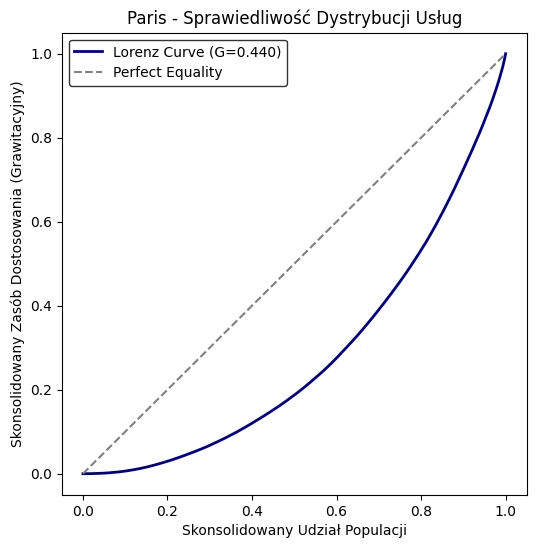

PARIS -> Wynik izolacji dojazdowej transport publiczny = GINI: 0.4400


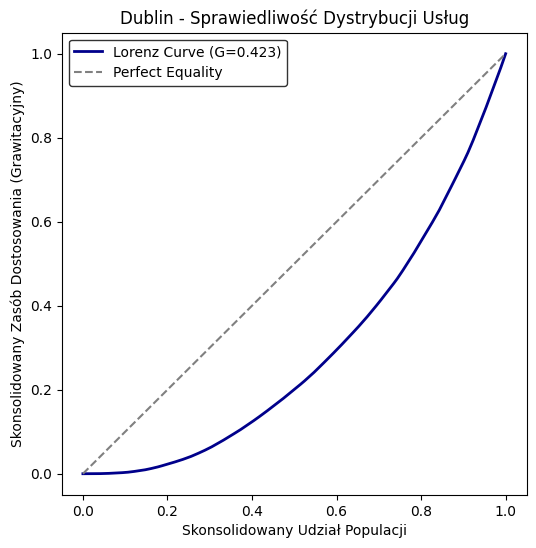

DUBLIN -> Wynik izolacji dojazdowej transport publiczny = GINI: 0.4231


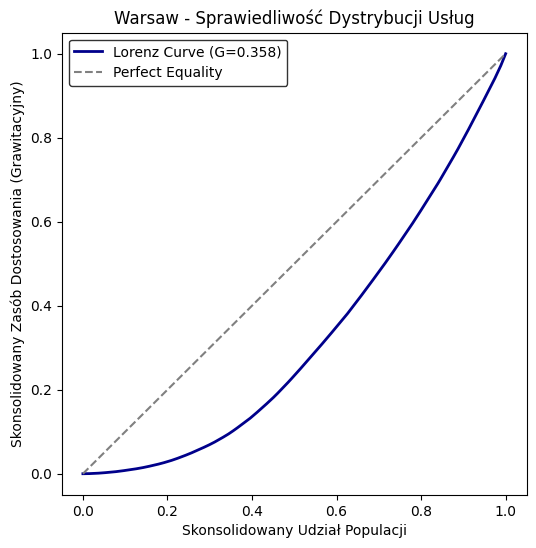

WARSAW -> Wynik izolacji dojazdowej transport publiczny = GINI: 0.3578


In [3]:
def calculate_gini_lorenz(df, target_col='accessibility_index', weight_col='O_pop', plot=False, city_name="City"):
    """
    Podejście Gini - Obliczenie dystrybucji krzywej Lorenz'a transportowej
    Należy posortować bazę najniższej dostepnosci i zakomulować sumę ludności.
    """
    data = df[[target_col, weight_col]].copy().dropna()
    data = data[(data[target_col] > 0) & (data[weight_col] > 0)]
    data = data.sort_values(by=target_col)
    
    # Cumulative Sums populacji (oś X) i podaży docelowej (Oś Y)
    data['cum_pop_share'] = data[weight_col].cumsum() / data[weight_col].sum()
    
    # Udział zasobu - przemnożenie ilości przez ludzi by zobaczyć ile dostepnosci skonsumowano
    data['resource'] = data[target_col] * data[weight_col]
    data['cum_acc_share'] = data['resource'].cumsum() / data['resource'].sum()
    
    # Powrót wektorów
    p = np.insert(data['cum_pop_share'].values, 0, 0)
    L = np.insert(data['cum_acc_share'].values, 0, 0)
    
    # Współczynnik Gini - Trapezoidal approximation
    # B dla trójkąta pod L (0.5 * pole trapezu dx(Y1+Y2)) => G = 1 - 2*AUC
    auc = np.sum(0.5 * (p[1:] - p[:-1]) * (L[1:] + L[:-1]))
    gini = 1.0 - 2.0 * auc
    
    if plot:
        plt.style.use('default') # Ustawiamy jasny motyw dla Gini
        plt.figure(figsize=(6, 6), facecolor='white')
        plt.plot(p, L, lw=2, label=f'Lorenz Curve (G={gini:.3f})', color='darkblue')
        plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Equality')
        plt.title(f"{city_name.capitalize()} - Sprawiedliwość Dystrybucji Usług")
        plt.xlabel("Skonsolidowany Udział Populacji")
        plt.ylabel("Skonsolidowany Zasób Dostosowania (Grawitacyjny)")
        plt.legend(frameon=True, facecolor='white', edgecolor='black')
        # Zapis jeżeli potrzeba: plt.savefig(..., facecolor='white')
        plt.show()
        
    return gini, p, L

for c in CITIES:
    if c in db:
        g, p, L = calculate_gini_lorenz(db[c], city_name=c, plot=True)
        print(f"{c.upper()} -> Wynik izolacji dojazdowej transport publiczny = GINI: {g:.4f}")

## 3. Mapy Nierówności Społeczno-Przestrzennych - Bivariate Mapping

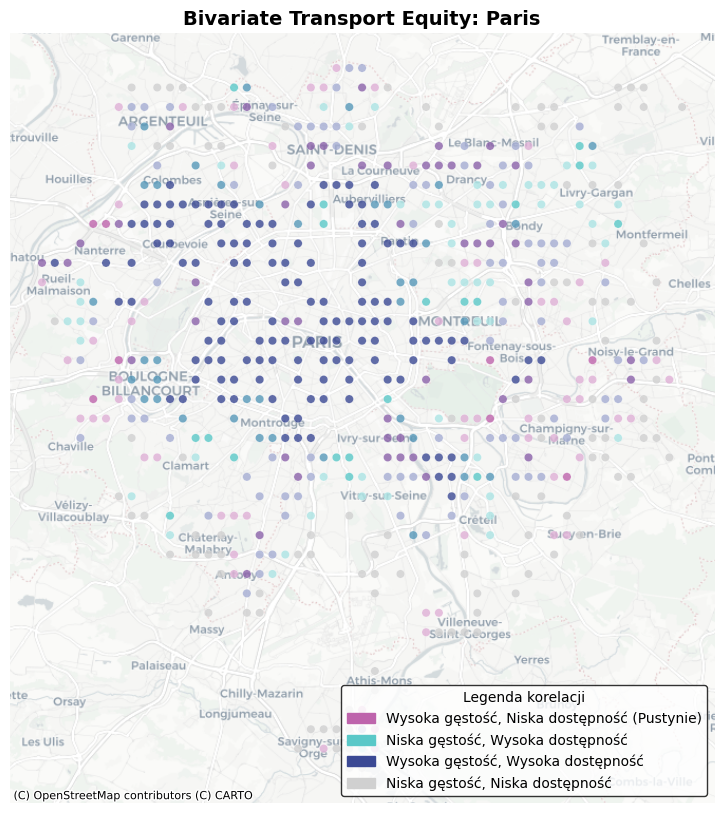

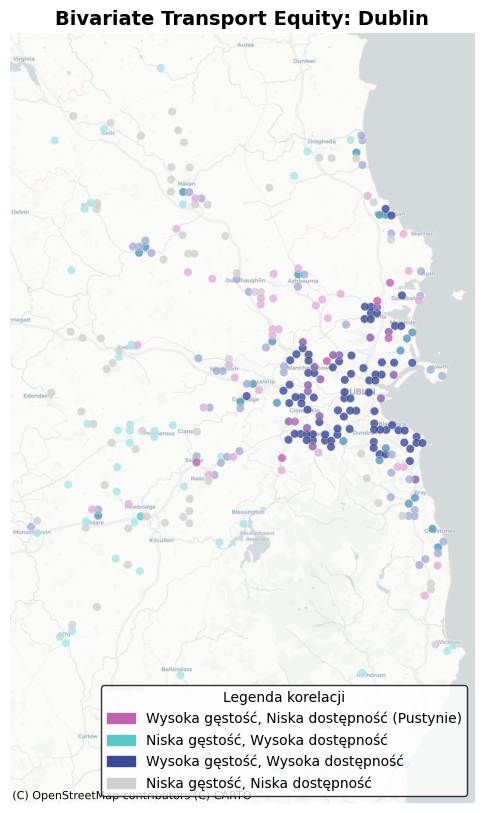

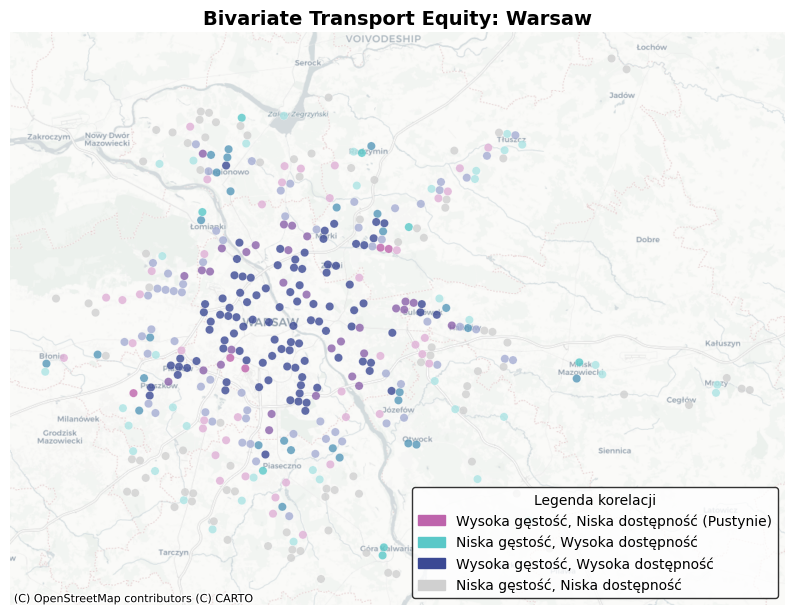

In [4]:
# Funkcja tworząca macierz przestrzeni 3x3 krzyżując warunek A (Access) i B (Density/Pop)
import matplotlib.patches as mpatches

def bivariate_mapping(gdf, city):
    # Wygenerowanie siatki na docelowe przestrzenie map na dysk
    out_pth = OUTPUTS_E5 / city / "maps"
    out_pth.mkdir(parents=True, exist_ok=True)
    
    plt.style.use('default') # Ustawiamy jasny motyw
    
    # Standaryzacja kolumn - aby zapobiec 0 rzucimy log1p żeby wyciągnąć odchyły
    acc = np.log1p(gdf['accessibility_index'])
    pop = np.log1p(gdf['O_pop'])
    
    # Quantiles do wyznaczenia Tiers
    q_acc = mc.Quantiles(acc, k=3).yb
    q_pop = mc.Quantiles(pop, k=3).yb
    
    # Kodowanie bivariate (od A1 do C3)
    bv_colors = {
       (0, 0): '#d0d0d0', (1, 0): '#ace4e4', (2, 0): '#5ac8c8',
       (0, 1): '#dfb0d6', (1, 1): '#a5add3', (2, 1): '#5698b9', 
       (0, 2): '#be64ac', (1, 2): '#8b62aa', (2, 2): '#3b4994'  
    }
    
    # Mapowanie kolorów dla siatki
    color_map = [bv_colors.get((pop_tier, acc_tier), '#ffffff') for pop_tier, acc_tier in zip(q_pop, q_acc)]
    gdf['bv_color'] = color_map
    
    # Rysowanie Warstwy Z podkładem sieciowym Contextily
    fi, ax = plt.subplots(figsize=(10, 10))
    gdf_plot = gdf.to_crs(epsg=3857) # Pseudo-Mercator dla OSM
    gdf_plot.plot(color=gdf['bv_color'], edgecolor='white', linewidth=0.2, alpha=0.8, ax=ax)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    ax.set_axis_off()
    plt.title(f"Bivariate Transport Equity: {city.capitalize()}", fontdict={'weight':'bold', 'fontsize': 14})
    
    # Legenda dla ekstremów Bivariate 3x3
    legend_elements = [
        mpatches.Patch(color='#be64ac', label='Wysoka gęstość, Niska dostępność (Pustynie)'),
        mpatches.Patch(color='#5ac8c8', label='Niska gęstość, Wysoka dostępność'),
        mpatches.Patch(color='#3b4994', label='Wysoka gęstość, Wysoka dostępność'),
        mpatches.Patch(color='#d0d0d0', label='Niska gęstość, Niska dostępność')
    ]
    ax.legend(handles=legend_elements, loc='lower right', title="Legenda korelacji", frameon=True, facecolor='white', edgecolor='black')
    
    plt.savefig(out_pth / "bivariate_equity_map.png", dpi=250, bbox_inches='tight')
    plt.show()

for c in CITIES:
    if c in db:
        bivariate_mapping(db[c], c)

### 3B. Różnicowe Mapy Cieplne (Difference Bivariate Maps)
Wizualizacja ujawniająca przestrzenne ukryte wykluczenie po zastosowaniu dynamicznego modelu C.

In [ ]:
# --- NOWA METODA KOMPARATYSTYCZNA: Różnicowe Mapy Cieplne (Deviation Heatmaps) ---
def plot_difference_heatmap(gdf, city, compare_cols=('RDI_C_vs_A', 'Model C a Model A (Captive Rider)'), out_pth=None):
    """
    Wyświetla Mapę Cieplną różnic między modelem Dynamicznym (Zamożnościowym) a modelem Sztywnym.
    Obszary czerwone oznaczają wykluczenie ukryte przez uśrednione modele, obszary niebieskie to wskaźnik zawyżony.
    """
    col, title_suffix = compare_cols
    
    if col not in gdf.columns:
        print(f"  ✗ Brak kolumny wariancyjnej {col} dla {city}. Pomijam heatmapę różnicową.")
        return
    
    gdf_plot = gdf.dropna(subset=[col]).to_crs(epsg=3857) # Web Mercator
    
    # Ustalamy granice kolorystyczne symetrycznie, by 0 było na środku (białe)
    vmax = max(abs(gdf_plot[col].min()), abs(gdf_plot[col].max()))
    if pd.isna(vmax) or vmax == 0:
        vmax = 0.5
        
    vmin = -vmax
    
    # Tworzenie wykresu
    fi, ax = plt.subplots(figsize=(12, 10))
    
    # Rysowanie mapy (Czerwony - straty względem spłaszczonego modelu; Niebieski - obiektywne mniejsze straty dla bogatych)
    plot = gdf_plot.plot(
        column=col,
        cmap='RdBu', # Red-Blue diverging colormap (Czerwony - ma do zyskania najwiecej na nowym modelu, Niebieski - na odwrot)
        vmin=vmin,
        vmax=vmax,
        edgecolor='black',
        linewidth=0.1,
        alpha=0.85,
        ax=ax,
        legend=True,
        legend_kwds={
            'label': f"Wskaźnik Względnej Różnicy (RDI)\n<0 (Czerwone): Straty na dostępności dla najbiedniejszych",
            'orientation': "vertical",
            'shrink': 0.7
        }
    )
    
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    ax.set_axis_off()
    
    city_cap = city.capitalize()
    plt.title(f"Różnicowa Mapa Cieplna Dostępności (Deviation Heatmap) - {city_cap}\n{title_suffix}", fontsize=14, weight='bold', pad=15)
    
    if out_pth:
        plt.savefig(out_pth / f"deviation_heatmap_{col}_{city}.png", dpi=250, bbox_inches='tight')
    plt.show()

# Wygenerowanie Map Różnicowych
for c in CITIES:
    if c in db:
        out_pth = OUTPUTS_E5 / c / "maps"
        out_pth.mkdir(parents=True, exist_ok=True)
        print(f"\n{'='*40}\nGenerowanie Map Różnicowych dla {c.upper()}\n{'='*40}")
        plot_difference_heatmap(db[c], c, compare_cols=('RDI_C_vs_A', 'Model C a Model A (Captive Rider)'), out_pth=out_pth)
        plot_difference_heatmap(db[c], c, compare_cols=('RDI_C_vs_B', 'Model C a Model B (Oportunistyczny)'), out_pth=out_pth)


## 4. Analiza Komparatywna Rynków Systemu: Wykresy (Box-Plot)

C:\Users\Michc\AppData\Local\Temp\ipykernel_34152\2293856168.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_df, x="city", y="log_access", palette="mako", inner="quartile")


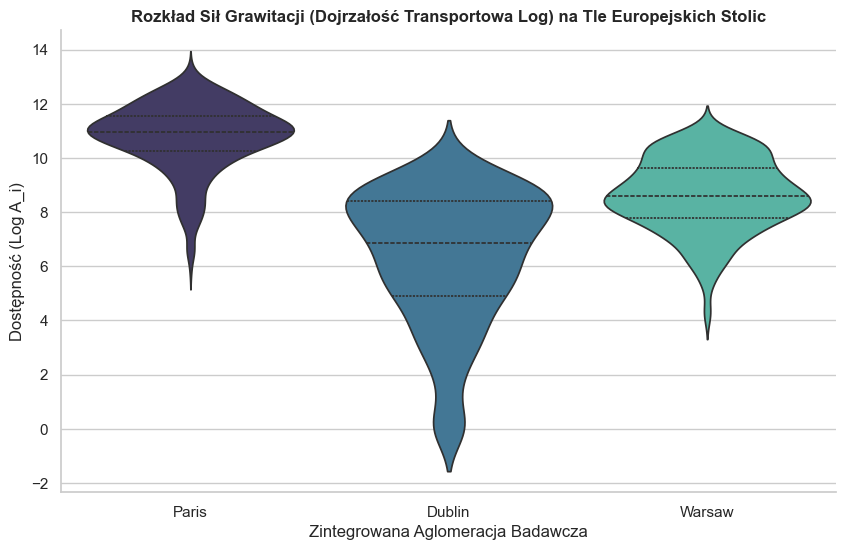

In [5]:
combined = []
for c in CITIES:
    if c in db:
        temp = db[c].copy()
        temp['city'] = c.capitalize()
        # Wyciągamy na światło logarytmiczne bo rynki mogą uciekać od skali Wilsona
        temp['log_access'] = np.log1p(temp['accessibility_index'])
        combined.append(temp.drop(columns=['geometry']))

combined_df = pd.concat(combined, ignore_index=True)

plt.style.use('default')
sns.set_theme(style="whitegrid") # Wymuszamy jasny motyw Seaborn
plt.figure(figsize=(10, 6), facecolor='white')

sns.violinplot(data=combined_df, x="city", y="log_access", palette="mako", inner="quartile")
plt.title("Rozkład Sił Grawitacji (Dojrzałość Transportowa Log) na Tle Europejskich Stolic", fontdict={'weight': 'bold'})
plt.ylabel("Dostępność (Log A_i)")
plt.xlabel("Zintegrowana Aglomeracja Badawcza")
sns.despine()

plot_pth = OUTPUTS_E5 / 'comparison'
plot_pth.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_pth / "violin_city_comparison.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()